# GraphRAG evaluation against six baselines

This notebook evaluates the **saved predictions** from the same pipelines as
`poster_method_comparison.ipynb`. GraphRAG is the method of interest; SapBERT,
BioLORD + context, AI context + BioLORD, BM25, BM25 + fuzzy, and Jaccard are baselines.
ICD9 and ICD10 are evaluated separately throughout. No model or service calls are made.

**Reading order:** settings → label/data audit → metrics → separate dataset results →
GraphRAG retrieval/filter/reranking diagnostics → worked examples → exports.

Run all cells using the project Python environment. Required packages: pandas, numpy,
pyarrow, matplotlib, IPython, and Jupyter/ipykernel. Inputs are the two dataset-specific
checkpoints, source CSVs, and optional GraphRAG JSONL logs under `data/` (or
`CONCEPT_NORM_DATA_DIR`). Figures are saved as PNG and SVG; numeric results as CSV.

The implementation lives in
[`notebook_evaluation.py`](src/concept_normalisation/notebook_evaluation.py).
This notebook keeps the settings, evaluation sequence, explanations, and results visible;
the module handles data checks, metric calculations, plotting, and trace rendering.
Install the project with `pip install -e ".[evaluation]"` before running the notebook.


In [2]:
from IPython.display import display
from concept_normalisation import notebook_evaluation as evaluation

ROOT = evaluation.find_repository_root()
DATA_DIR = evaluation.resolve_data_directory(ROOT)
OUTPUT = DATA_DIR / "output" / "graphrag_baseline_evaluation"
SPECS = evaluation.dataset_specs(DATA_DIR)

# Edit the evaluation settings here.
KS = [1, 2, 3, 4, 5]
MRR_DEPTH = 5
PRIMARY_VIEW = "unique query"  # Alternatively: "row".

evaluation.configure_display()
print("Inputs:", DATA_DIR)
print("Exports:", OUTPUT)

Inputs: F:\Repos\concept-normalisation\data
Exports: F:\Repos\concept-normalisation\data\output\graphrag_baseline_evaluation


## 1. Define the evaluation carefully

For a query, let **G** be its set of valid SNOMED targets and **Pₖ** the first K
distinct predicted IDs in the method's saved order.

| Metric | Per-query definition | Interpretation |
|---|---|---|
| Recall@K | `len(set(Pₖ) & G) / len(G)` | Fraction of all labelled targets recovered |
| Top-1 Accuracy | `1` if the first prediction is in G, else `0` | Whether the first answer is acceptable |
| MRR@5 | `1 / rank` of the first valid target within five predictions, else `0` | How early an acceptable answer appears |

All scores use **exact SNOMED ID equality**. We do not give credit for ancestors or
descendants. For singleton labels, Recall@1 equals Top-1 Accuracy; for multiple labels
it generally does not. Hit@K (any target found) is a different metric from set recall.

The mapping direction matters: many SNOMED targets may map to one ICD code, but the
reverse ICD→SNOMED evaluation has a **set of valid targets**. The audit below measures
the actual set sizes instead of assuming cardinality from the dataset name. With 16
targets and only five predictions, even a perfect list has Recall@5 ≤ 5/16.

We retain each method's saved order, remove repeated IDs before computing concept ranks,
and never sort the LLM's output by its copied retrieval scores. Empty results and missing
row predictions score zero on the common labelled cohort; their coverage is reported.
An entirely absent method column is reported as unavailable. Unlabelled rows are excluded
for every method. Malformed results fail loudly instead of being silently counted as misses.

Two averaging views are reported: **unique query** averages within each (diagnosis text,
ICD code), then gives each such query equal weight; **row** gives every checkpoint row
equal weight. These are descriptive results for these datasets, not independent-patient
estimates or evidence of statistical significance.

In [3]:
# A small worked example: one of two targets is found at rank 2.
example_scores = evaluation.score_ids(
    ids=["other_concept", "target_a"],
    gold={"target_a", "target_b"},
    ks=[1, 2],
    depth=MRR_DEPTH,
)
display(example_scores)  # Top-1 = 0, MRR = 0.5, Recall@2 = 0.5.

{'Top-1 Accuracy': 0.0, 'MRR@5': 0.5, 'Recall@1': 0.0, 'Recall@2': 0.5}

## 2. Audit both datasets before comparing methods

The truth join checks that each ICD code has an unambiguous target set and that the
checkpoint agrees with the source CSV. Source identifiers are read as strings to preserve
large SNOMED IDs. Exact duplicate source rows are counted, not silently removed.

The existing ICD9 checkpoint has legacy numeric-conversion artifacts: for example,
`564.00` became `564.0` and SNOMED `66657009` became `66657009.0`. We restore the exact
ICD code from the source CSV using (diagnosis ID, stay ID, diagnosis string), validate the
join as many-to-one, and report how many keys changed. Integral `.0` SNOMED strings are
repaired only below the exact-integer float limit; potentially rounded large IDs fail.

In [4]:
datasets, audit, coverage = evaluation.load_datasets(SPECS, MRR_DEPTH)
display(audit)
display(coverage)

,dataset,source rows,checkpoint rows,restored ICD keys,exact duplicate source rows,excluded unlabelled rows,labelled rows,unique queries,singleton queries,multi-target queries,min targets,max targets
0,ICD9,6356,6356,701,4335,220,6136,49,49,0,1,1
1,ICD10,9637,9637,0,8909,0,9637,29,0,29,3,16


,dataset,method,status,labelled rows,missing predictions,empty predictions,min distinct predictions,max distinct predictions,rows with fewer than 5
0,ICD9,SapBERT,available,6136,0,0,1,4,6136
1,ICD9,BioLORD + context,available,6136,0,0,1,5,6123
2,ICD9,AI context + BioLORD,available,6136,0,0,1,5,6091
3,ICD9,BM25,available,6136,0,0,2,5,5236
4,ICD9,BM25 + fuzzy,available,6136,0,0,2,5,5535
5,ICD9,Jaccard,available,6136,0,0,2,5,4705
6,ICD9,GraphRAG,available,6136,0,0,3,5,334
7,ICD10,SapBERT,available,9637,0,0,1,5,9597
8,ICD10,BioLORD + context,available,9637,0,0,1,5,9433
9,ICD10,AI context + BioLORD,available,9637,0,0,2,5,6618


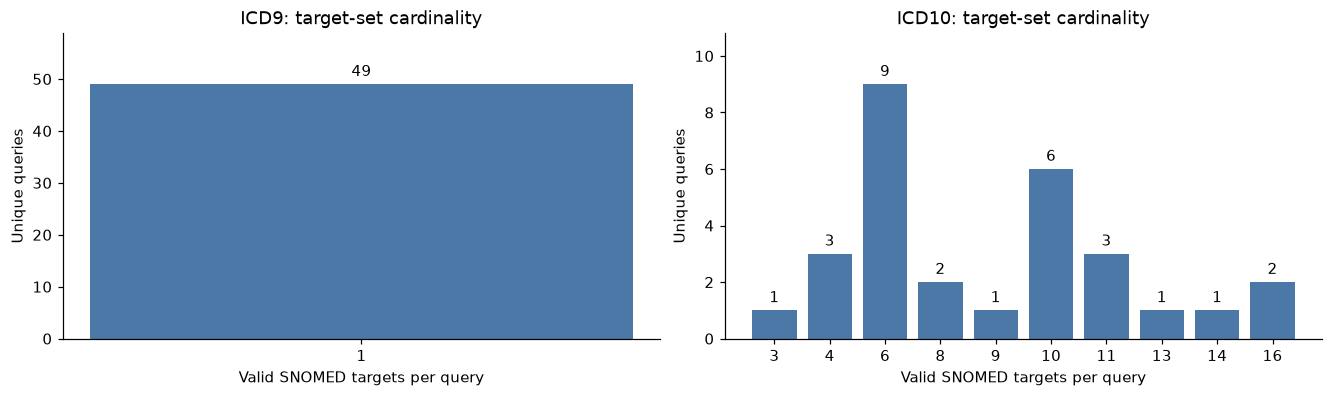

In [5]:
evaluation.plot_target_cardinality(datasets, OUTPUT)

## 3. Compute comparable scores

Every available method uses the same labelled rows within a dataset. MRR is truncated
at the shared saved depth; shorter lists are not padded with invented candidates.
The detailed table retains row IDs and query keys for paired comparisons and error analysis.

In [6]:
per_row, per_query, scores = evaluation.evaluate_methods(
    datasets, ks=KS, mrr_depth=MRR_DEPTH,
)

## 4a. ICD9: GraphRAG versus the baselines

Both averaging views are shown below. The chart uses the selected primary view and
highlights GraphRAG in red. Values are on a 0–1 scale, including MRR.

n  Top-1 Accuracy   MRR@5  Recall@1  \
view         method                                                         
unique query SapBERT                 49          0.2449  0.2993    0.2449   
             BioLORD + context       49          0.1633  0.2014    0.1633   
             AI context + BioLORD    49          0.2245  0.2721    0.2245   
             BM25                    49          0.2245  0.2619    0.2245   
             BM25 + fuzzy            49          0.1837  0.2126    0.1837   
             Jaccard                 49          0.0612  0.1037    0.0612   
             GraphRAG                49          0.2857  0.3265    0.2857   
row          SapBERT               6136          0.2052  0.2312    0.2052   
             BioLORD + context     6136          0.0846  0.1336    0.0846   
             AI context + BioLORD  6136          0.1389  0.1856    0.1389   
             BM25                  6136          0.1998  0.2240    0.1998   
             BM25 + fuzzy          6136          0.0991  0.1280    0.0991   
             Jaccard               6136          0.0106  0.0625    0.0106   
             GraphRAG              6136          0.2101  0.3000    0.2101   

                                   Recall@2  Recall@3  Recall@4  Recall@5  
view         method                                                        
unique query SapBERT                 0.3265    0.3673    0.3673    0.3673  
             BioLORD + context       0.2041    0.2449    0.2449    0.2653  
             AI context + BioLORD    0.2857    0.3061    0.3469    0.3469  
             BM25                    0.2653    0.2857    0.3265    0.3265  
             BM25 + fuzzy            0.2041    0.2449    0.2653    0.2653  
             Jaccard                 0.0612    0.1429    0.2041    0.2041  
             GraphRAG                0.3469    0.3469    0.3878    0.3878  
row          SapBERT                 0.2539    0.2588    0.2588    0.2588  
             BioLORD + context       0.1437    0.2009    0.2009    0.2027  
             AI context + BioLORD    0.2104    0.2135    0.2533    0.2533  
             BM25                    0.2166    0.2293    0.2756    0.2756  
             BM25 + fuzzy            0.0993    0.1729    0.1899    0.1899  
             Jaccard                 0.0106    0.0680    0.1992    0.1992  
             GraphRAG                0.3343    0.3343    0.4457    0.4457

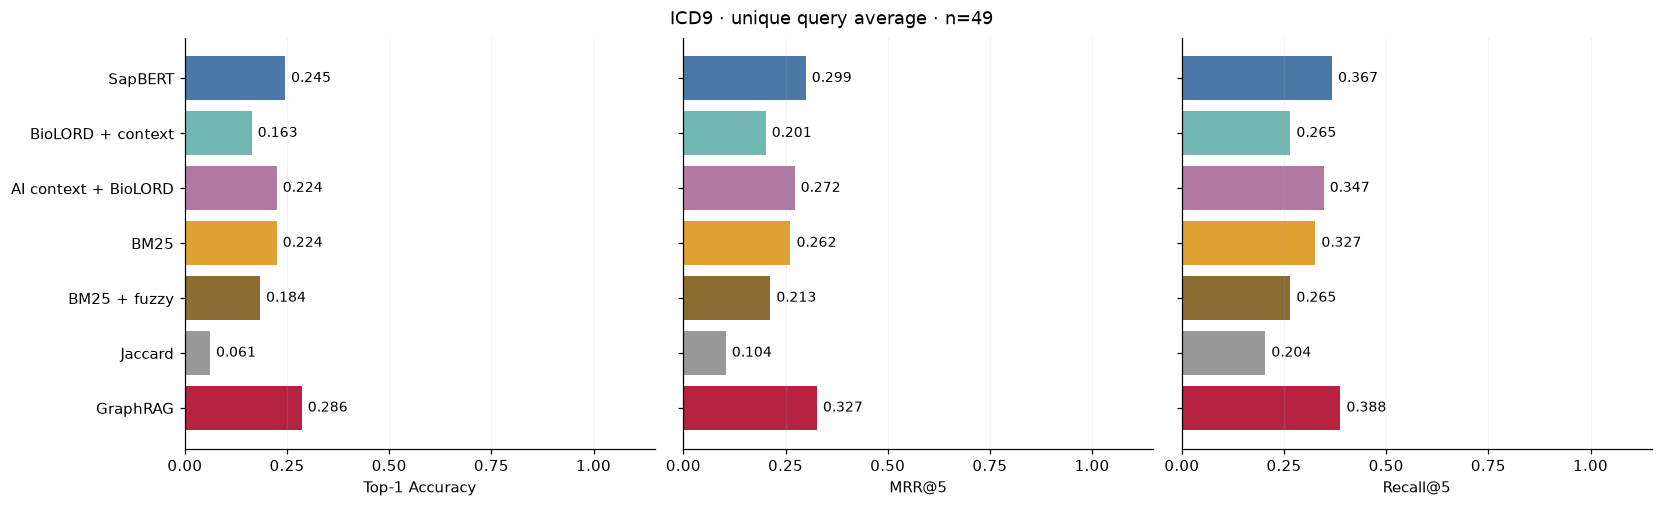

In [7]:
display(evaluation.dataset_score_table(scores, "ICD9", KS, MRR_DEPTH))
evaluation.plot_method_comparison(
    scores, "ICD9", ks=KS, mrr_depth=MRR_DEPTH,
    view=PRIMARY_VIEW, output_dir=OUTPUT,
)

## 4b. ICD10: GraphRAG versus the baselines

Both averaging views are shown below. The chart uses the selected primary view and
highlights GraphRAG in red. Values are on a 0–1 scale, including MRR.

n  Top-1 Accuracy   MRR@5  Recall@1  \
view         method                                                         
unique query SapBERT                 29          0.3793  0.4483    0.0485   
             BioLORD + context       29          0.4483  0.5374    0.0695   
             AI context + BioLORD    29          0.3103  0.4580    0.0511   
             BM25                    29          0.1379  0.2586    0.0157   
             BM25 + fuzzy            29          0.1034  0.1897    0.0135   
             Jaccard                 29          0.0000  0.0690    0.0000   
             GraphRAG                29          0.5862  0.6218    0.0739   
row          SapBERT               9637          0.9011  0.9227    0.0626   
             BioLORD + context     9637          0.1469  0.5504    0.0193   
             AI context + BioLORD  9637          0.0658  0.4097    0.0093   
             BM25                  9637          0.5790  0.6045    0.0382   
             BM25 + fuzzy          9637          0.0378  0.3205    0.0044   
             Jaccard               9637          0.0000  0.0166    0.0000   
             GraphRAG              9637          0.9517  0.9555    0.0695   

                                   Recall@2  Recall@3  Recall@4  Recall@5  
view         method                                                        
unique query SapBERT                 0.0620    0.0939    0.0939    0.0939  
             BioLORD + context       0.0916    0.0959    0.0986    0.0986  
             AI context + BioLORD    0.0952    0.1089    0.1194    0.1286  
             BM25                    0.0510    0.0625    0.0625    0.0625  
             BM25 + fuzzy            0.0337    0.0337    0.0337    0.0337  
             Jaccard                 0.0069    0.0161    0.0161    0.0161  
             GraphRAG                0.0891    0.1141    0.1455    0.1556  
row          SapBERT                 0.0689    0.0750    0.0750    0.0750  
             BioLORD + context       0.0737    0.0754    0.0758    0.0758  
             AI context + BioLORD    0.0385    0.0733    0.0908    0.0915  
             BM25                    0.0461    0.0487    0.0487    0.0487  
             BM25 + fuzzy            0.0416    0.0416    0.0416    0.0416  
             Jaccard                 0.0024    0.0036    0.0036    0.0036  
             GraphRAG                0.0756    0.0805    0.0873    0.0900

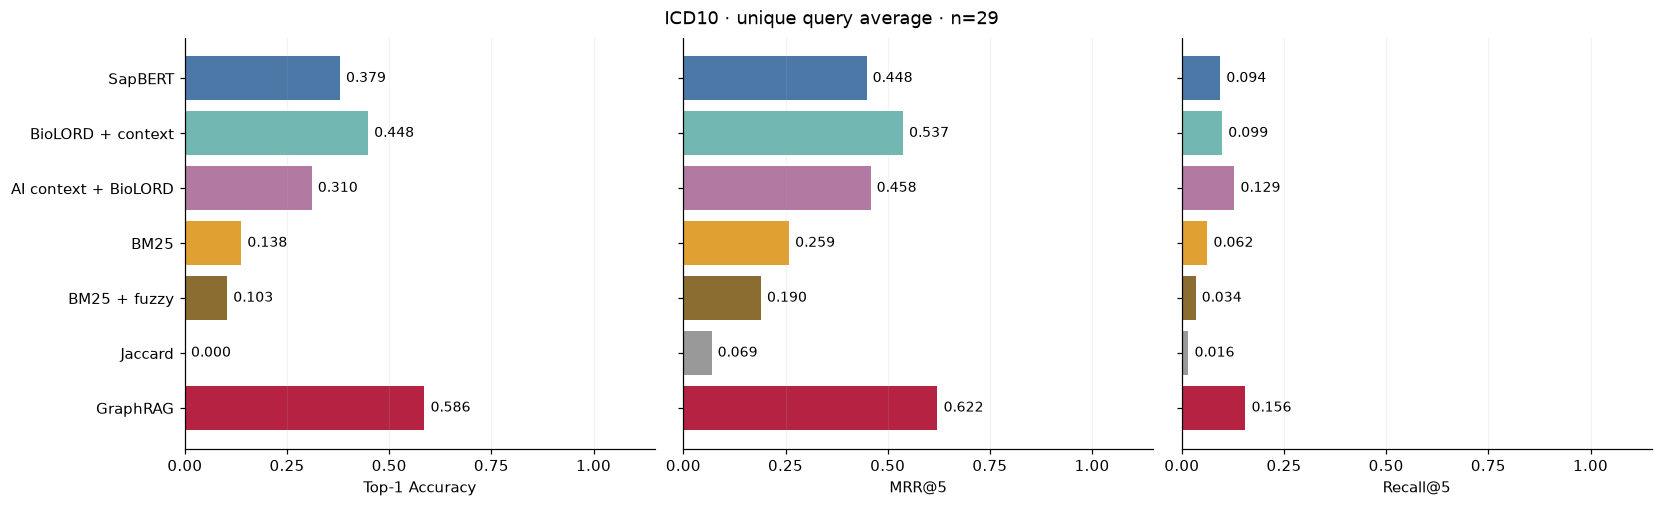

In [8]:
display(evaluation.dataset_score_table(scores, "ICD10", KS, MRR_DEPTH))
evaluation.plot_method_comparison(
    scores, "ICD10", ks=KS, mrr_depth=MRR_DEPTH,
    view=PRIMARY_VIEW, output_dir=OUTPUT,
)

## 5. Recall curves and paired differences

The dashed ceiling is the mean of `min(K, |G|) / |G|` for each dataset: set recall is
structurally constrained by target-set size. It is not a method's measured score.
The difference table subtracts each baseline from GraphRAG on the same queries.
Positive differences favour GraphRAG. We make no significance claim from these small,
repeated datasets.

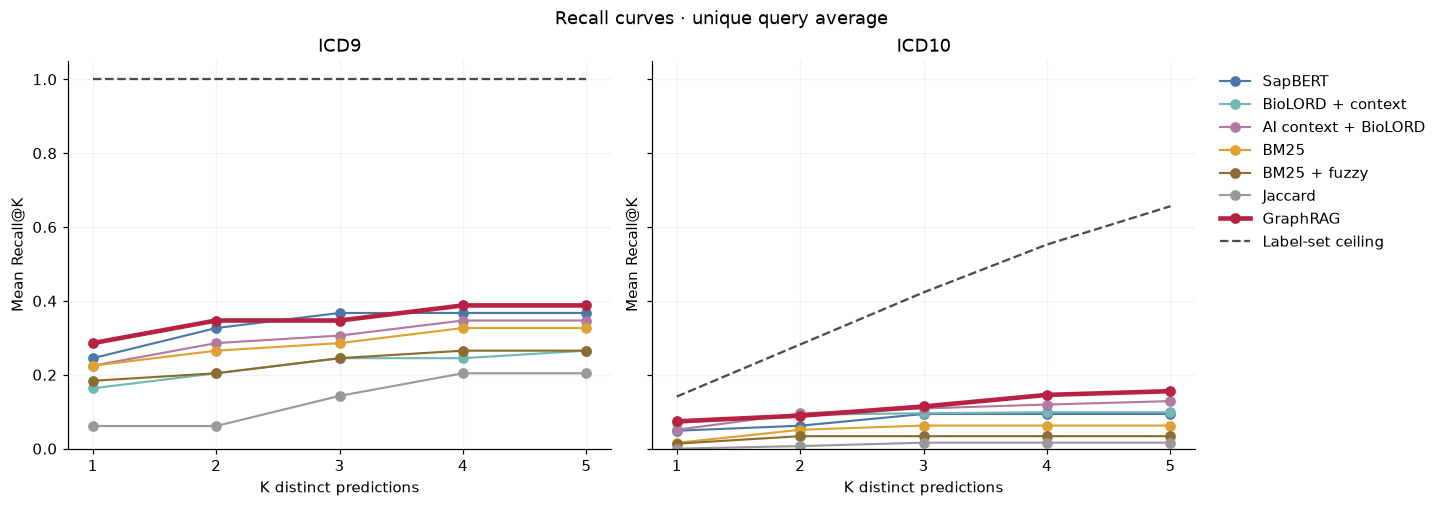

,dataset,baseline,Top-1 Accuracy,MRR@5,Recall@5
0,ICD9,SapBERT,0.0408,0.0272,0.0204
1,ICD9,BioLORD + context,0.1224,0.1252,0.1224
2,ICD9,AI context + BioLORD,0.0612,0.0544,0.0408
3,ICD9,BM25,0.0612,0.0646,0.0612
4,ICD9,BM25 + fuzzy,0.1020,0.1139,0.1224
5,ICD9,Jaccard,0.2245,0.2228,0.1837
6,ICD10,SapBERT,0.2069,0.1736,0.0617
7,ICD10,BioLORD + context,0.1379,0.0845,0.0570
8,ICD10,AI context + BioLORD,0.2759,0.1638,0.0270
9,ICD10,BM25,0.4483,0.3632,0.0931


In [9]:
evaluation.plot_recall_curves(datasets, scores, KS, PRIMARY_VIEW, OUTPUT)

deltas = evaluation.baseline_differences(scores, KS, MRR_DEPTH, PRIMARY_VIEW)
display(deltas.round(4))

## 6. How GraphRAG makes its selection

The implementation in `graphrag_matcher.py` and `graphrag_queries.py` follows these steps:

1. **Clean the diagnosis.** Replace `/` with `or`, collapse whitespace, and trim.
2. **Retrieve twice.** Base and enriched vector indexes each participate in a hybrid
   vector/full-text retrieval. Both use the same full-text index.
3. **Attach graph evidence.** Fetch parents, grandparents, children, finding sites,
   morphologies, causes, clinical course, and interpreted entities. These are context,
   not additional selectable candidates.
4. **Fuse by SCTID.** Keep one record per candidate, retaining base/enriched scores and
   provenance. The fused score is the maximum of the two available scores. The current
   implementation preserves insertion order (base first, then enriched-only entries);
   **it does not sort the fused list by score**.
5. **Filter.** Keep candidates with score ≥ the configured threshold (also keep missing
   scores). The log records the actual surviving list.
6. **LLM selection/reranking.** The prompt asks the LLM to rank only surviving candidates
   using the diagnosis and graph evidence, copy their original scores, and provide brief
   reasons. The final list order defines rank. The copied score is not a probability
   or an LLM confidence value. The matcher truncates to its configured maximum.

The current prompt asks for candidate membership but the matcher does not enforce it.
We therefore explicitly audit final IDs against the supplied pool. Reported reasons are
the model's saved explanations, not proof of its internal reasoning.

**Historical limits:** logs contain fused candidates, survivors, matches, and timestamps,
but not a run ID, threshold, model version, raw per-channel ranks, or full prompt.
We select the latest log whose ordered final IDs match the checkpoint for that cleaned
query. This provides a consistency check, not proof of identical run provenance.
Unmatched/ambiguous queries are reported and excluded only from stage diagnostics,
never from the main method comparison. No historical settings are invented.

In [10]:
trace_records, trace_coverage = evaluation.load_traces(datasets, SPECS)

display(
    trace_coverage.groupby(["dataset", "status"]).agg(
        queries=("query_key", "size"),
        rows=("row_count", "sum"),
    )
)

,,queries,rows
dataset,status,,
ICD10,matched final IDs,29,9637
ICD9,matched final IDs,49,6136


## 7. Locate GraphRAG's successes and losses

These diagnostics give each matched unique query equal weight. Pool recall uses **all**
IDs in the named pool, so it is not Recall@K for a fixed K and should not be compared as
an equal-budget baseline. The stage plot asks whether **any** valid target survives each
step. The outcome chart separates retrieval misses, filtering losses, selection losses,
lower-ranked successes, and correct first answers.

queries  mean_candidates  any_target_rate  \
dataset stage                                                        
ICD9    Retrieved union       49          11.0816           0.4490   
        After filter          49          10.3061           0.3878   
        Final list            49           4.8980           0.3878   
        Final top-1           49           1.0000           0.2857   
ICD10   Retrieved union       29          10.9655           0.7931   
        After filter          29          10.5172           0.7931   
        Final list            29           5.0000           0.7241   
        Final top-1           29           1.0000           0.5862   

                         mean_pool_recall  
dataset stage                              
ICD9    Retrieved union            0.4490  
        After filter               0.3878  
        Final list                 0.3878  
        Final top-1                0.2857  
ICD10   Retrieved union            0.2352  
        After filter               0.2352  
        Final list                 0.1556  
        Final top-1                0.0739

,outside_pool_count,filter_ids_not_retrieved
dataset,,
ICD10,2,0
ICD9,0,0


**Candidate membership violations (main scores retain the saved outputs):**

,dataset,diagnosis_text,outside_pool_ids,outside_pool_count,filter_ids_not_retrieved
53,ICD10,oncology - GU tumors - prostate CA,39949008,1,0
62,ICD10,infectious diseases - GI infections - diarrhea due to infection - C. difficile colitis - lab confirmed,404907005,1,0


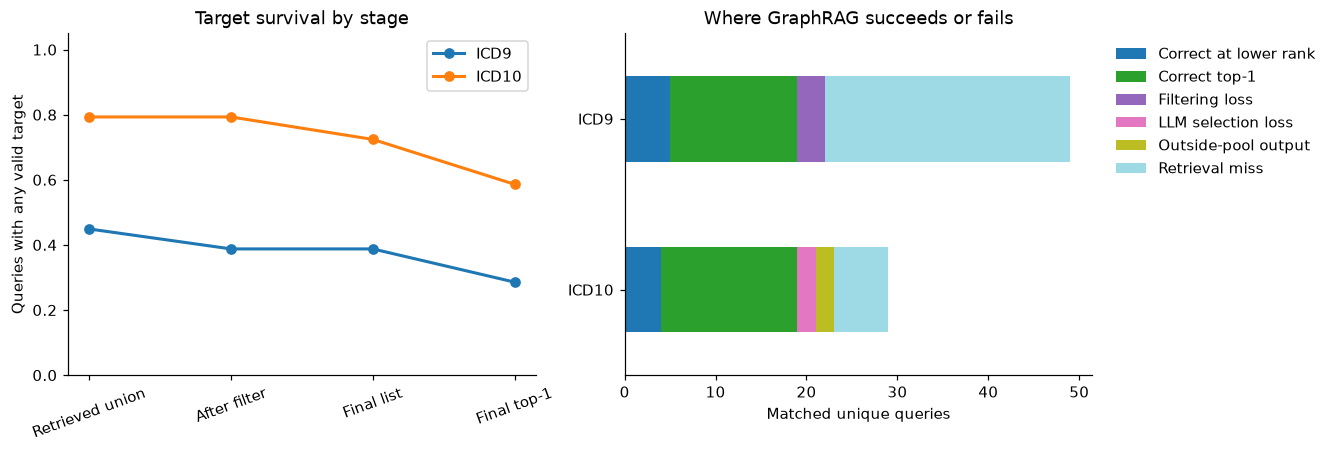

In [11]:
stages, outcomes, membership = evaluation.analyse_traces(trace_records)
evaluation.show_trace_diagnostics(stages, outcomes, membership, OUTPUT)

## 8. Walk through individual decisions

For each dataset, the cells below automatically select one correct first answer and one
failure, plus one outside-pool output if present (when available). To inspect any other query, set `EXAMPLE_QUERIES` to exact
diagnosis strings from `outcomes` and rerun the two example cells below.

Read the tables from top to bottom: input/targets → fused candidate scores and provenance
→ retained/excluded candidates → graph context supplied → final ranking and saved reasons.
Candidate `input_position` is its **fused-list position**, not a global score rank.
The position plot connects surviving candidates to their final ranks; it makes promotions
and omissions visible without claiming that input order was a sorted retrieval ranking.

In [12]:
# Leave these lists empty for automatically selected examples.
# To inspect a particular diagnosis, paste its exact text into the relevant list.
EXAMPLE_QUERIES = {"ICD9": [], "ICD10": []}
examples = evaluation.select_examples(trace_records, EXAMPLE_QUERIES)

### ICD9 — cardiovascular - arrhythmias - atrial fibrillation

1. Cleaned input: cardiovascular - arrhythmias - atrial fibrillation
Ground truth (evaluation only; not supplied as labels to GraphRAG): 49436004
Log timestamp: 2026-09-29T13:44:04.306357 | line: 2
Historical threshold/top_k/model are not recorded in this log.


**2–5. Retrieved candidates, fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,sent_to_LLM,final_rank,is_target
0,1,49436004,Atrial fibrillation (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,1.0,True
1,2,282825002,Paroxysmal atrial fibrillation (disorder),"[base, enriched]",0.983814,0.983814,0.983814,True,4.0,False
2,3,17366009,Atrial arrhythmia (disorder),[base],0.978566,NaN,0.978566,True,NaN,False
3,4,164889003,Electrocardiographic atrial fibrillation (finding),[base],0.966954,NaN,0.966954,True,NaN,False
4,5,40593004,Fibrillation (disorder),[base],0.964228,NaN,0.964228,True,NaN,False
5,6,233911009,Non-rheumatic atrial fibrillation (disorder),[base],0.962684,NaN,0.962684,True,NaN,False
6,7,314208002,Rapid atrial fibrillation (disorder),"[base, enriched]",0.961935,0.985740,0.985740,True,5.0,False
7,8,233910005,Lone atrial fibrillation (disorder),"[base, enriched]",0.958240,0.998803,0.998803,True,2.0,False
8,9,300996004,Controlled atrial fibrillation (disorder),[enriched],NaN,0.989009,0.989009,True,3.0,False
9,10,72654001,Supraventricular arrhythmia (disorder),[enriched],NaN,0.984567,0.984567,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations**

,sctid,fsn,reason,score,rank,is_target,in_LLM_pool
0,49436004,Atrial fibrillation (disorder),Exact semantic match to the diagnosis string 'atrial fibrillation'. It is the parent concept for all specific types of AF listed in other candidates and has the highest retrieval score (1.0).,1.000000,1,True,True
1,233910005,Lone atrial fibrillation (disorder),"A specific subtype of atrial fibrillation with a very high enriched score (0.9988). While 'lone' is not in the input string, the high score suggests strong contextual relevance, but it is less general than the parent concept.",0.998803,2,False,True
2,300996004,Controlled atrial fibrillation (disorder),"A specific subtype of atrial fibrillation with a high enriched score (0.989). The qualifier 'controlled' is not present in the input, making it less likely than the general term but still highly relevant.",0.989009,3,False,True
3,282825002,Paroxysmal atrial fibrillation (disorder),"A specific subtype of atrial fibrillation with a high score (0.9838). The qualifier 'paroxysmal' is not in the input string, so it ranks below the general term.",0.983814,4,False,True
4,314208002,Rapid atrial fibrillation (disorder),"A specific subtype of atrial fibrillation with a high enriched score (0.9857). The qualifier 'rapid' is not in the input string, placing it below the general term.",0.985740,5,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


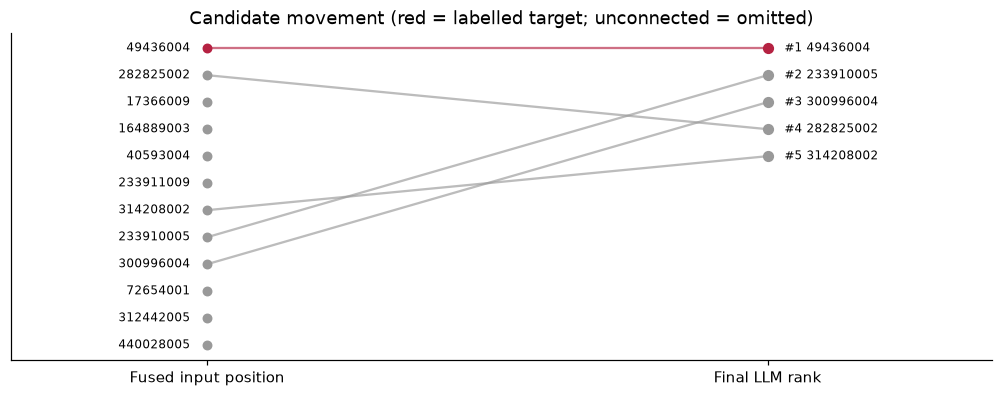

### ICD9 — cardiovascular - arrhythmias - ventricular tachycardia

1. Cleaned input: cardiovascular - arrhythmias - ventricular tachycardia
Ground truth (evaluation only; not supplied as labels to GraphRAG): 66657009
Log timestamp: 2026-09-29T13:43:29.237450 | line: 1
Historical threshold/top_k/model are not recorded in this log.


**2–5. Retrieved candidates, fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,sent_to_LLM,final_rank,is_target
0,1,25569003,Ventricular tachycardia (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,1.0,False
1,2,6624005,Ventricular tachyarrhythmia (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,2.0,False
2,3,164895002,Electrocardiographic ventricular tachycardia (finding),"[base, enriched]",0.989822,0.989822,0.989822,True,3.0,False
3,4,426525004,Sustained ventricular tachycardia (disorder),"[base, enriched]",0.969127,0.982520,0.982520,True,5.0,False
4,5,708124001,Recurrent ventricular tachycardia (disorder),"[base, enriched]",0.967018,0.991942,0.991942,True,4.0,False
5,6,44103008,Ventricular arrhythmia (disorder),[base],0.953321,NaN,0.953321,True,NaN,False
6,7,444658006,Nonsustained ventricular tachycardia (disorder),[base],0.953233,NaN,0.953233,True,NaN,False
7,8,233907003,Induced ventricular tachycardia (disorder),"[base, enriched]",0.947786,0.961441,0.961441,True,NaN,False
8,9,429046004,History of sustained ventricular tachycardia (situation),[enriched],NaN,0.974613,0.974613,True,NaN,False
9,10,233906007,Familial ventricular tachycardia (disorder),[enriched],NaN,0.967538,0.967538,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations**

,sctid,fsn,reason,score,rank,is_target,in_LLM_pool
0,25569003,Ventricular tachycardia (disorder),"Exact lexical match to the diagnosis string 'ventricular tachycardia'. It is the most specific disorder concept without adding unverified qualifiers like 'sustained', 'recurrent', or 'induced'.",1.000000,1,False,True
1,6624005,Ventricular tachyarrhythmia (disorder),"Highly relevant synonym for ventricular tachycardia in the context of arrhythmias. It is a sibling concept to VT and captures the same clinical entity, though 'tachycardia' is more precise than 'tachyarrhythmia'.",1.000000,2,False,True
2,164895002,Electrocardiographic ventricular tachycardia (finding),"Represents the finding of VT on an ECG. While the diagnosis string implies a disorder, this is a strong candidate if the context is diagnostic findings, but it is less direct than the disorder concept itself.",0.989822,3,False,True
3,708124001,Recurrent ventricular tachycardia (disorder),"A specific subtype of VT. The diagnosis string does not specify 'recurrent', so this is less likely than the general term, but still a valid child concept.",0.991942,4,False,True
4,426525004,Sustained ventricular tachycardia (disorder),"A specific subtype of VT. The diagnosis string does not specify 'sustained', making it less likely than the general term, but it is a common clinical presentation.",0.982520,5,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


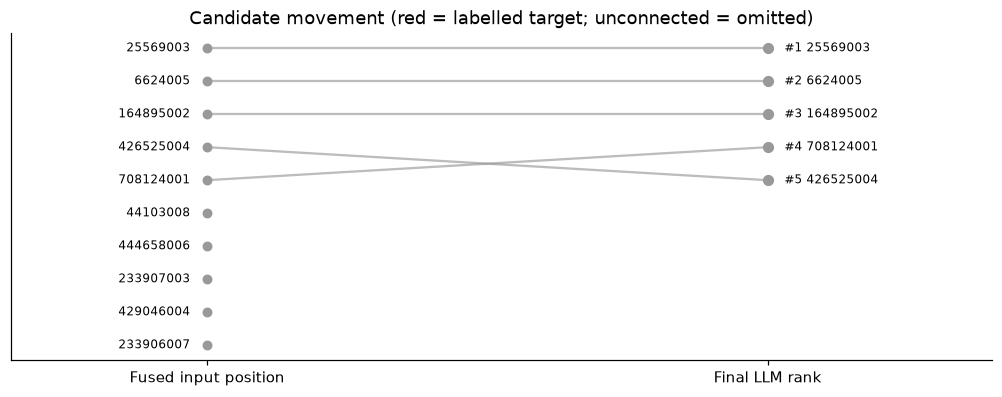

### ICD10 — oncology - chest tumors - primary lung cancer

1. Cleaned input: oncology - chest tumors - primary lung cancer
Ground truth (evaluation only; not supplied as labels to GraphRAG): 1259726005, 254622008, 254626006, 254632001, 254634000, 254635004, 707451005, 722528008, 93734005, 93880001
Log timestamp: 2026-09-29T14:26:22.813381 | line: 1
Historical threshold/top_k/model are not recorded in this log.


**2–5. Retrieved candidates, fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,sent_to_LLM,final_rank,is_target
0,1,93880001,Primary malignant neoplasm of lung (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,1.0,True
1,2,1259727001,Primary non-small cell lung cancer (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,2.0,False
2,3,1259754003,Primary squamous non-small cell lung cancer (disorder),"[base, enriched]",0.983630,0.983630,0.983630,True,NaN,False
3,4,372110008,"Primary malignant neoplasm of lower lobe, bronchus or lung (disorder)","[base, enriched]",0.968886,0.981659,0.981659,True,NaN,False
4,5,93734005,Primary malignant neoplasm of bronchus (disorder),[base],0.953962,NaN,0.953962,True,NaN,True
5,6,890529001,Primary malignant neoplasm of right lung (disorder),"[base, enriched]",0.951035,0.972502,0.972502,True,3.0,False
6,7,890528009,Primary malignant neoplasm of left lung (disorder),"[base, enriched]",0.947885,0.966396,0.966396,True,4.0,False
7,8,93986008,Primary malignant neoplasm of respiratory tract (disorder),[base],0.943877,NaN,0.943877,True,NaN,False
8,9,415077006,History of primary malignant neoplasm of bronchus (situation),[enriched],NaN,0.979907,0.979907,True,NaN,False
9,10,1268348008,Primary small cell carcinoma of lung (disorder),[enriched],NaN,0.966360,0.966360,True,5.0,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations**

,sctid,fsn,reason,score,rank,is_target,in_LLM_pool
0,93880001,Primary malignant neoplasm of lung (disorder),This is the most accurate general match. The diagnosis 'primary lung cancer' maps directly to 'Primary malignant neoplasm of lung'. It covers all histological types without assuming specific subtypes like NSCLC or SCLC which are not mentioned in the input.,1.000000,1,True,True
1,1259727001,Primary non-small cell lung cancer (disorder),"While 'non-small cell' is a specific subtype not explicitly stated in the input, it is a very common form of primary lung cancer. However, it is less precise than the general term because it excludes small cell carcinoma.",1.000000,2,False,True
2,890529001,Primary malignant neoplasm of right lung (disorder),This concept specifies the laterality (right lung) which is not present in the diagnosis string. It is a valid child of the general concept but adds unverified specificity.,0.972502,3,False,True
3,890528009,Primary malignant neoplasm of left lung (disorder),"Similar to the right lung concept, this specifies laterality (left lung) not found in the input. It is equally specific but less general than the top match.",0.966396,4,False,True
4,1268348008,Primary small cell carcinoma of lung (disorder),This represents a specific histological subtype (small cell) not mentioned in the input. It is ranked lower than the general term and NSCLC due to the assumption of a specific pathology.,0.966360,5,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,0.1,0.1,0.1,0.1,0.1


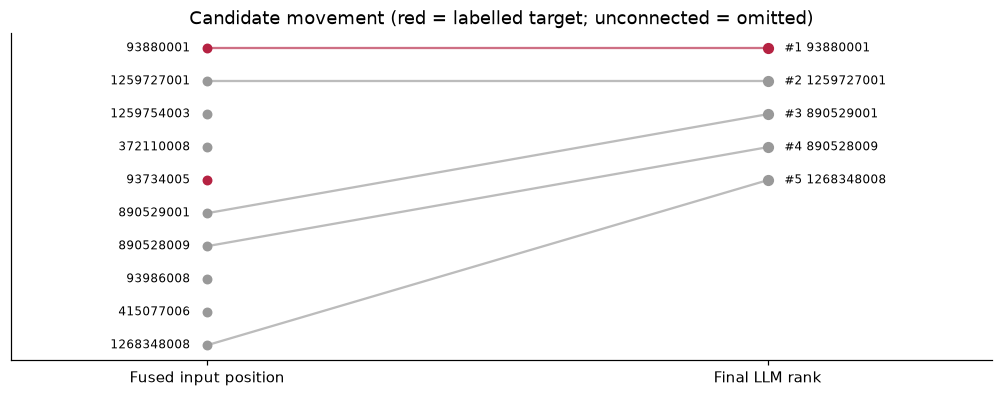

### ICD10 — oncology - skin, muscle and skeletal tumors - melanoma - nodular

1. Cleaned input: oncology - skin, muscle and skeletal tumors - melanoma - nodular
Ground truth (evaluation only; not supplied as labels to GraphRAG): 1197324006, 254730000, 302837001, 307593001, 398696001, 403924008, 405843009, 424190005, 443493003, 94360002, 94459006
Log timestamp: 2026-09-29T14:29:28.682683 | line: 6
Historical threshold/top_k/model are not recorded in this log.


**2–5. Retrieved candidates, fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,sent_to_LLM,final_rank,is_target
0,1,254731001,Nodular malignant melanoma of skin (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,1.0,False
1,2,2142002,Nodular melanoma (morphologic abnormality),"[base, enriched]",0.999926,1.000000,1.000000,True,3.0,False
2,3,1259379002,Primary nodular malignant melanoma of skin (disorder),"[base, enriched]",0.978892,0.970318,0.978892,True,2.0,False
3,4,253046007,Malignant myomatous tumor (morphologic abnormality),"[base, enriched]",0.968536,0.968608,0.968608,True,NaN,False
4,5,372244006,Malignant melanoma (disorder),"[base, enriched]",0.966276,0.945425,0.966276,True,4.0,False
5,6,1162635006,Malignant melanoma (morphologic abnormality),"[base, enriched]",0.952122,0.952193,0.952193,True,5.0,False
6,7,363495004,Malignant neoplasm of muscle (disorder),[base],0.944539,NaN,0.944539,True,NaN,False
7,8,443493003,Metastatic malignant melanoma (disorder),[base],0.942624,NaN,0.942624,True,NaN,True
8,9,302847003,Rhabdomyosarcoma (disorder),[enriched],NaN,0.955194,0.955194,True,NaN,False
9,10,404014008,Malignant fibrous histiocytoma of skin (disorder),[enriched],NaN,0.943406,0.943406,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations**

,sctid,fsn,reason,score,rank,is_target,in_LLM_pool
0,254731001,Nodular malignant melanoma of skin (disorder),"Perfect semantic match. The diagnosis specifies 'melanoma' (morphology) and 'skin' (site), with 'nodular' as the subtype. This concept explicitly combines all three elements: Nodular + Malignant Melanoma + Skin.",1.000000,1,False,True
1,1259379002,Primary nodular malignant melanoma of skin (disorder),"Highly specific match including 'Primary'. While the diagnosis string does not explicitly state 'primary', in the context of a new diagnosis listing site and morphology, primary is the default assumption. This concept is a child of the top candidate and adds specificity.",0.978892,2,False,True
2,2142002,Nodular melanoma (morphologic abnormality),"Matches the morphology ('Nodular melanoma') but lacks the specific body site ('skin'). In SNOMED CT, this is a morphology concept rather than a disorder of a specific site, making it less precise for a diagnosis string that includes 'skin'.",1.000000,3,False,True
3,372244006,Malignant melanoma (disorder),"Matches the general disease ('Malignant melanoma') but lacks the specific subtype ('nodular') and site ('skin'). It is a parent concept to more specific diagnoses, making it less precise.",0.966276,4,False,True
4,1162635006,Malignant melanoma (morphologic abnormality),"Matches the general morphology ('Malignant melanoma') but lacks the subtype ('nodular') and site ('skin'). Like the previous candidate, it is too broad compared to the specific diagnosis string.",0.952193,5,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


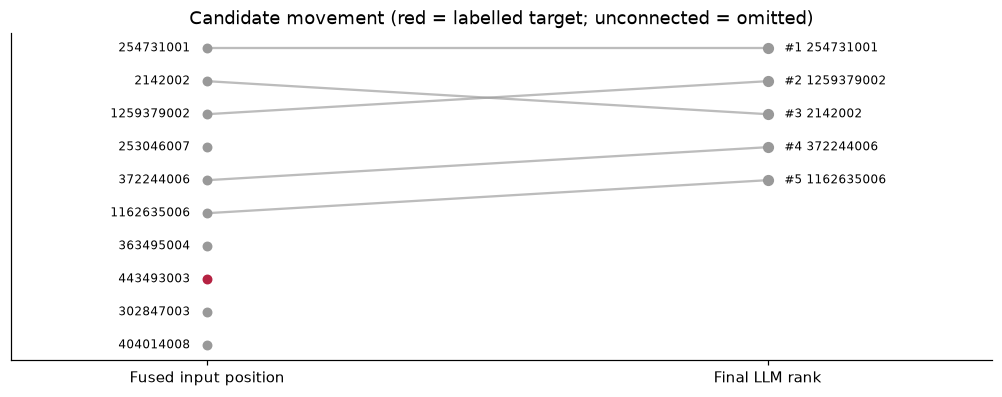

### ICD10 — oncology - GU tumors - prostate CA

1. Cleaned input: oncology - GU tumors - prostate CA
Ground truth (evaluation only; not supplied as labels to GraphRAG): 1098981000119101, 254900004, 399490008, 427492003, 93974005, 94513006, 94661005, 96901000119105
Log timestamp: 2026-09-29T14:28:50.383050 | line: 5
Historical threshold/top_k/model are not recorded in this log.


**2–5. Retrieved candidates, fusion, and observed filtering**

,input_position,sctid,fsn,found_by,base_score,enriched_score,fused_score,sent_to_LLM,final_rank,is_target
0,1,93974005,Primary malignant neoplasm of prostate (disorder),"[base, enriched]",1.000000,0.986142,1.000000,True,2.0,True
1,2,254900004,Carcinoma of prostate (disorder),"[base, enriched]",1.000000,1.000000,1.000000,True,1.0,True
2,3,1259388006,Primary carcinoma of prostate (disorder),"[base, enriched]",0.990484,0.970972,0.990484,True,3.0,False
3,4,399490008,Adenocarcinoma of prostate (disorder),[base],0.980647,NaN,0.980647,True,NaN,True
4,5,314969001,Local recurrence of malignant neoplasm of prostate (disorder),"[base, enriched]",0.980128,1.000000,1.000000,True,NaN,False
5,6,1098981000119101,Recurrent malignant neoplasm of prostate (disorder),"[base, enriched]",0.976728,0.994349,0.994349,True,NaN,True
6,7,1259672003,Primary adenocarcinoma of prostate (disorder),[base],0.969844,NaN,0.969844,True,5.0,False
7,8,1237422007,Metastatic carcinoma to prostate (disorder),[base],0.969782,NaN,0.969782,True,NaN,False
8,9,428262008,History of malignant neoplasm of prostate (situation),[enriched],NaN,0.970548,0.970548,True,NaN,False
9,10,419043006,Urological oncology (qualifier value),[enriched],NaN,0.965887,0.965887,True,NaN,False


**3. Actual graph evidence supplied for every surviving candidate**

**6. Final LLM order and its saved explanations**

,sctid,fsn,reason,score,rank,is_target,in_LLM_pool
0,254900004,Carcinoma of prostate (disorder),"The diagnosis string 'prostate CA' is a direct abbreviation for 'Prostate Carcinoma'. This concept's description explicitly lists 'CA - Carcinoma of prostate' and 'Prostate carcinoma', making it the most semantically precise match. It has a perfect retrieval score.",1.000000,1,True,True
1,93974005,Primary malignant neoplasm of prostate (disorder),"'CA' implies malignancy, and in the absence of 'metastatic' or 'recurrent' qualifiers, 'primary' is the standard assumption. This concept represents the primary malignant neoplasm of the prostate and has a perfect retrieval score. It is slightly broader than carcinoma but highly accurate.",1.000000,2,True,True
2,1259388006,Primary carcinoma of prostate (disorder),"This concept combines the specificity of 'carcinoma' with the assumption of 'primary' origin. It is a child of both 'Carcinoma of prostate' and 'Primary malignant neoplasm of prostate', offering high precision for the input string.",0.990484,3,False,True
3,39949008,Adenocarcinoma of prostate (disorder),"While 'prostate CA' usually refers to adenocarcinoma clinically, the input string does not specify the histological subtype. This concept is a specific child of carcinoma and has a high score, but it assumes more detail than present in the query.",0.980647,4,False,False
4,1259672003,Primary adenocarcinoma of prostate (disorder),"This is the most specific concept in the list, combining primary origin and adenocarcinoma histology. It is ranked lower than the general carcinoma concepts because it assumes a specific histological subtype not explicitly mentioned in 'prostate CA'.",0.969844,5,False,True


,Top-1 Accuracy,MRR@5,Recall@1,Recall@2,Recall@3,Recall@4,Recall@5
0,1.0,1.0,0.125,0.25,0.25,0.25,0.25


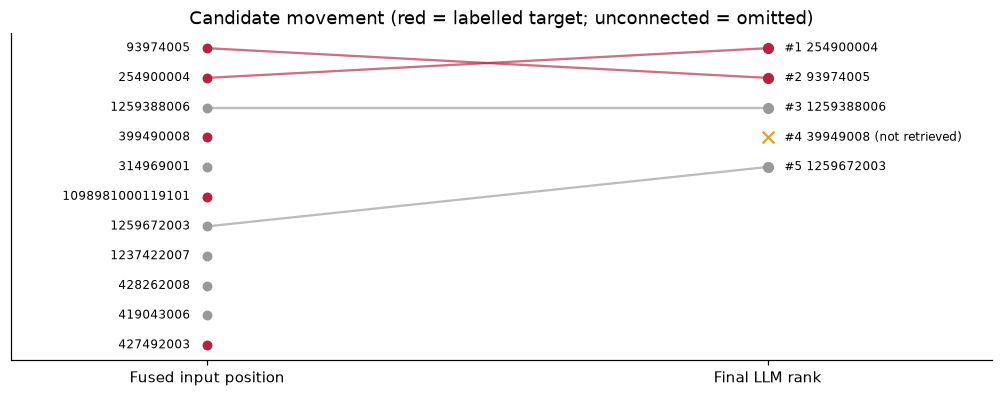

In [13]:
for trace in examples:
    evaluation.explain_trace(trace, ks=KS, mrr_depth=MRR_DEPTH, output_dir=OUTPUT)

## 9. Inspect errors and interpret the comparison

Use the outcome table to select additional examples. A correct target absent from the
retrieved union cannot be recovered by a candidate-constrained reranker; a target lost
after filtering points to a different issue than one passed to the LLM but not selected.
Check outside-pool outputs before making that interpretation.

Compare methods **within each dataset first**. ICD10's larger valid-target sets make its
recall scale different from ICD9's, even when Top-1 Accuracy is high. Also compare the
two averaging views: differences indicate sensitivity to repeated queries. The baseline
names describe their pipeline inputs, not a controlled ablation of GraphRAG. In particular,
these results alone cannot attribute a gain specifically to graph context or the LLM;
that would require matched retrieval-only and no-graph-context experiments.

In [14]:
if not outcomes.empty:
    errors = outcomes[outcomes.outcome.ne("Correct top-1")]
    display(errors.reset_index(drop=True))

evaluation.print_comparison_summary(scores, KS, MRR_DEPTH, PRIMARY_VIEW)

,dataset,query_key,diagnosis_text,outcome
0,ICD9,"(cardiovascular - arrhythmias - ventricular tachycardia, 427.1)",cardiovascular - arrhythmias - ventricular tachycardia,Retrieval miss
1,ICD9,"(cardiovascular - arrhythmias - atrial fibrillation - with rapid ventricular response, 427.31)",cardiovascular - arrhythmias - atrial fibrillation - with rapid ventricular response,Filtering loss
2,ICD9,"(renal - disorder of urinary tract / renal system infection - lower urinary tract infection, 595.9)",renal - disorder of urinary tract / renal system infection - lower urinary tract infection,Retrieval miss
3,ICD9,"(infectious diseases - GU infections - lower urinary tract infection, 595.9)",infectious diseases - GU infections - lower urinary tract infection,Retrieval miss
4,ICD9,"(gastrointestinal - abdominal/ general - constipation, 564.00)",gastrointestinal - abdominal/ general - constipation,Retrieval miss
5,ICD9,"(cardiovascular - shock / hypotension - hypovolemia, 276.52)",cardiovascular - shock / hypotension - hypovolemia,Correct at lower rank
6,ICD9,"(cardiovascular - arrhythmias - atrial fibrillation - with controlled ventricular response, 427.31)",cardiovascular - arrhythmias - atrial fibrillation - with controlled ventricular response,Filtering loss
7,ICD9,"(cardiovascular - arrhythmias - sinus tachycardia, 785.0)",cardiovascular - arrhythmias - sinus tachycardia,Retrieval miss
8,ICD9,"(cardiovascular - arrhythmias - ventricular tachycardia - sustained, 427.1)",cardiovascular - arrhythmias - ventricular tachycardia - sustained,Retrieval miss
9,ICD9,(renal - disorder of urinary tract / renal system infection - lower urinary tract infection - likely bacte...,renal - disorder of urinary tract / renal system infection - lower urinary tract infection - likely bacterial,Retrieval miss


ICD9 (unique query):
  Top-1 Accuracy: GraphRAG 0.2857; best baseline SapBERT 0.2449; difference +0.0408
  MRR@5: GraphRAG 0.3265; best baseline SapBERT 0.2993; difference +0.0272
  Recall@5: GraphRAG 0.3878; best baseline SapBERT 0.3673; difference +0.0204
ICD10 (unique query):
  Top-1 Accuracy: GraphRAG 0.5862; best baseline BioLORD + context 0.4483; difference +0.1379
  MRR@5: GraphRAG 0.6218; best baseline BioLORD + context 0.5374; difference +0.0845
  Recall@5: GraphRAG 0.1556; best baseline AI context + BioLORD 0.1286; difference +0.0270


## 10. Save tables and reproducibility information

Exports go to a separate evaluation directory. The manifest records input hashes,
evaluation settings, package versions, and hashes of the current GraphRAG source. Source
hashes describe the code available during evaluation; historical model/run settings cannot
be recovered from these artifacts. Existing pipeline outputs and the poster notebook are
left intact. Rerunning this notebook refreshes its own named exports.

In [15]:
exports = {
    "dataset_audit": audit,
    "prediction_coverage": coverage,
    "method_scores": scores,
    "graphrag_minus_baselines": deltas,
    "per_row_scores": per_row,
    "per_query_scores": per_query,
    "trace_coverage": trace_coverage,
    "graphrag_stages": stages,
    "graphrag_outcomes": outcomes,
    "candidate_membership": membership,
}
evaluation.export_evaluation(
    exports, SPECS, ROOT, OUTPUT, ks=KS, mrr_depth=MRR_DEPTH, view=PRIMARY_VIEW,
)

Saved 10 tables, PNG/SVG figures, worked-example evidence, and manifest to F:\Repos\concept-normalisation\data\output\graphrag_baseline_evaluation
